# 🚢 Titanic Survival Prediction

## Machine Learning Classification Project

This project explores the Titanic dataset to analyze passenger survival patterns and build machine learning models capable of predicting survival outcomes.

The project follows a professional Data Science workflow including:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Logistic Regression
- Random Forest
- Model Evaluation
- Feature Importance Analysis

---

## Technologies Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

---

## Project Goal

The goal is not only to build predictive models, but also to understand the relationships between passenger characteristics and survival probability.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

from data.load_data import cargar_datos
from data.clean_data import revisar_nulos, imputar_datos

from features.build_features import (
    agregar_tamano_familia,
    agregar_is_alone,
    agregar_title
)

from visualization.plots import (
    plot_survival_by_family,
    plot_survival_by_sex,
    plot_survival_by_class,
    plot_age_distribution,
    plot_age_boxplot,
    plot_correlation_heatmap,
    plot_feature_importance
)

from models.train_model import entrenar_modelo
from models.random_forest_model import entrenar_random_forest
from models.evaluate_model import evaluar_modelo

# Load Dataset

In [2]:
df = cargar_datos('../data/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

Before cleaning and modeling the data, it is important to understand:

- Dataset dimensions
- Data types
- Missing values
- General structure

In [3]:
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows: 891
Columns: 12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
revisar_nulos(df)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 🧹 Data Cleaning

The dataset contains missing values in several variables.

Cleaning strategy:

- `Age` → median imputation
- `Embarked` → mode imputation
- `Cabin` → removed due to excessive missing values

In [7]:
df = imputar_datos(df)

In [8]:
revisar_nulos(df)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Feature Engineering

Feature engineering is the process of creating new variables from existing data in order to provide additional information to machine learning models.

Previous experiments showed that changing algorithms and tuning hyperparameters produced only limited improvements. Therefore, the focus shifted toward creating more informative features.

Three new features were engineered:

## FamilySize

`FamilySize` represents the total number of family members traveling together, including the passenger.

It is calculated as:

```python
FamilySize = SibSp + Parch + 1
```

where:

- `SibSp` = number of siblings/spouses aboard
- `Parch` = number of parents/children aboard
- `+1` accounts for the passenger themselves

**Hypothesis:**

Passengers traveling with family members may have had different survival probabilities compared to passengers traveling alone.

---

## IsAlone

`IsAlone` is a binary feature derived from `FamilySize`.

- `IsAlone = 1` if `FamilySize == 1`
- `IsAlone = 0` if `FamilySize > 1`

**Hypothesis:**

Passengers traveling alone may have experienced different survival outcomes compared to those traveling with relatives.

---

## Title

`Title` is extracted from the passenger's name and represents their social title.

Examples include:

- Mr
- Mrs
- Miss
- Master

Rare titles are grouped into a single category called `Rare`.

**Hypothesis:**

Titles may capture information related to age, gender, social status, and family role, all of which could influence survival probability.


In [33]:
df = agregar_tamano_familia(df)
df = agregar_is_alone(df)
df = agregar_title(df)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Mr



# Feature Engineering Analysis

## Objective

The objective of this phase was to determine whether the newly engineered features could provide additional predictive information about passenger survival.

Previous experiments showed that changing algorithms and tuning hyperparameters produced only marginal improvements. Therefore, the focus shifted toward improving the quality of the input features.

---

## Analysis of Title

Survival rate by title:

| Title | Survival Rate |
|--------|--------------:|
| Mrs | 79.2% |
| Miss | 69.8% |
| Master | 57.5% |
| Rare | 44.4% |
| Mr | 15.7% |

### Observation

Strong differences were observed between passenger titles. In particular, passengers with the title **Mr** showed a much lower survival rate compared to **Mrs** and **Miss**.

This suggests that `Title` contains highly informative signals related to survival.

---

## Analysis of IsAlone

Survival rate by IsAlone:

| IsAlone | Survival Rate |
|----------|--------------:|
| 0 | 50.6% |
| 1 | 30.4% |

### Observation

Passengers traveling with others had substantially higher survival rates than passengers traveling alone.

This indicates that `IsAlone` may contribute useful predictive information.

---

## Impact on Logistic Regression

After incorporating the new features:

- Accuracy remained approximately **0.80**.
- Recall for the survived class increased from **0.70** to **0.74**.
- F1-score increased slightly.

### Observation

Although overall accuracy did not change significantly, the model became better at identifying passengers who survived.

---

## Impact on Random Forest

After incorporating the new features:

- Accuracy increased to approximately **0.82**.
- Recall for the survived class increased to **0.80**.

### Observation

The engineered features provided additional information that improved model performance.

---

## Feature Importance Findings

Top Random Forest features:

| Feature | Importance |
|----------|----------:|
| Fare | 0.275 |
| Age | 0.230 |
| Title_Mr | 0.140 |
| Sex_male | 0.125 |
| Pclass | 0.083 |
| FamilySize | 0.068 |
| Title_Mrs | 0.033 |
| Title_Miss | 0.022 |
| IsAlone | 0.013 |
| Title_Rare | 0.005 |

### Observation

`Title_Mr` became one of the most important variables in the model, confirming that passenger titles contain strong predictive information.

In contrast, `IsAlone` showed relatively low importance, suggesting that much of its information was already captured by `FamilySize`.

---

## Conclusions

The results confirm that feature engineering produced greater improvements than changing algorithms alone.

### Key Findings

- `Title` was the most successful engineered feature.
- `IsAlone` contained useful information but contributed less than expected.
- Random Forest benefited more from the new features than Logistic Regression.
- Feature engineering proved to be a more effective strategy than additional hyperparameter tuning at this stage of the project.
- The performance improvements validated the importance of understanding the data before trying more complex algorithms.

# Exploratory Data Analysis (EDA)

## Survival Rate by Family Size

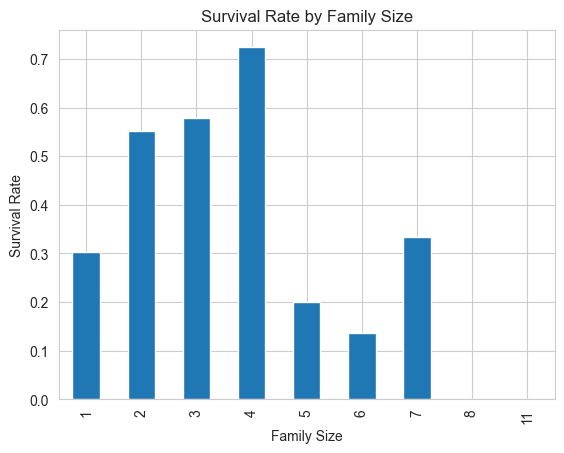

In [30]:
plot_survival_by_family(df)

### Observation

Passengers traveling with small families showed different survival patterns compared to passengers traveling alone or in large groups.

## Survival Rate by Sex

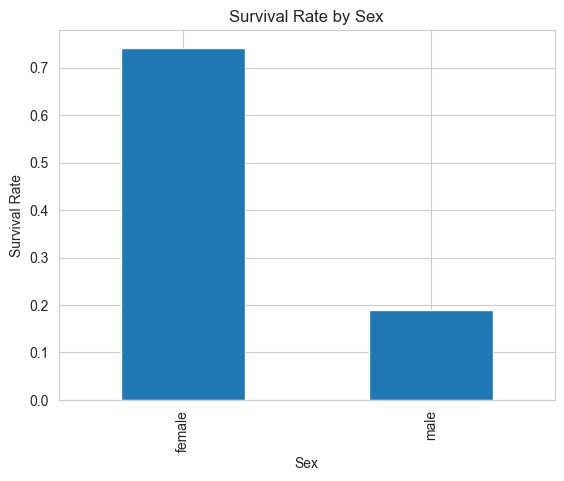

In [11]:
plot_survival_by_sex(df)

### Insight

Female passengers had a significantly higher survival rate compared to male passengers.

This suggests that sex is likely one of the strongest predictive variables in the dataset.

## Survival Rate by Passenger Class

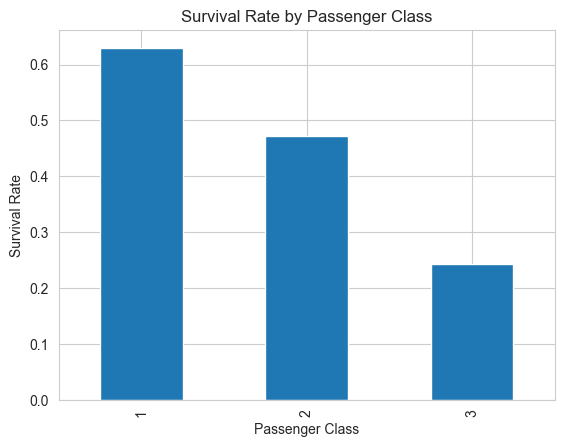

In [12]:
plot_survival_by_class(df)

### Insight

Passengers traveling in higher classes had greater survival probabilities.

This may reflect differences in cabin location, access to lifeboats, or social priority during evacuation.

## Survival Rate by Family Size

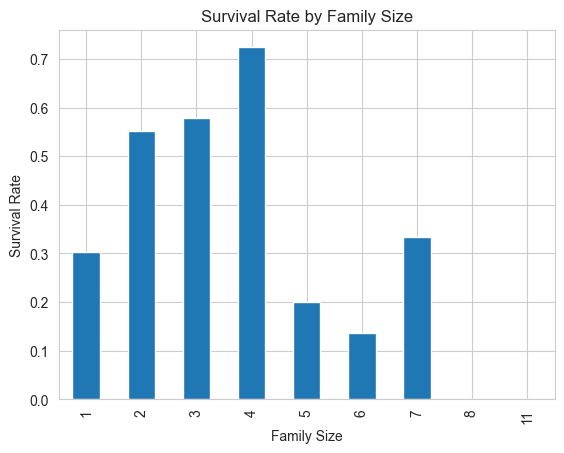

In [13]:
plot_survival_by_family(df)

### Insight

Passengers traveling in very large groups or completely alone appeared to have lower survival rates.

## Age Distribution

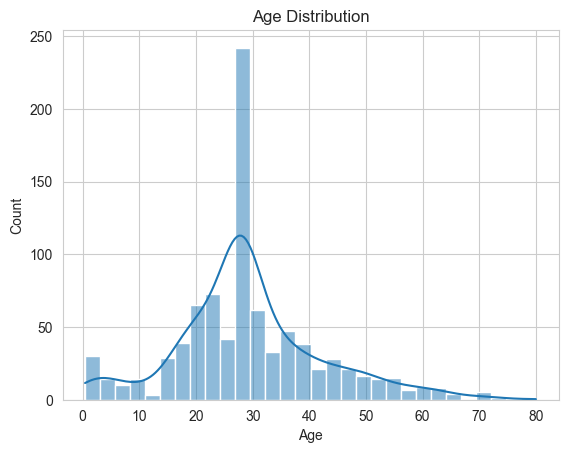

In [14]:
plot_age_distribution(df)

### Insight

Most passengers were concentrated in young adult age ranges, with fewer elderly passengers represented in the dataset.

## Age Boxplot

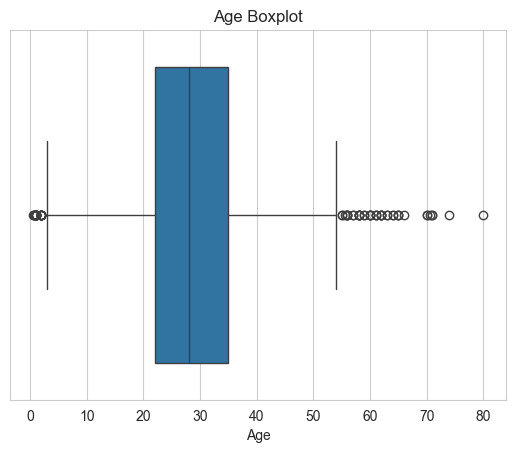

In [15]:
plot_age_boxplot(df)

### Insight

The boxplot reveals the presence of several age outliers, particularly among older passengers.

## Correlation Heatmap

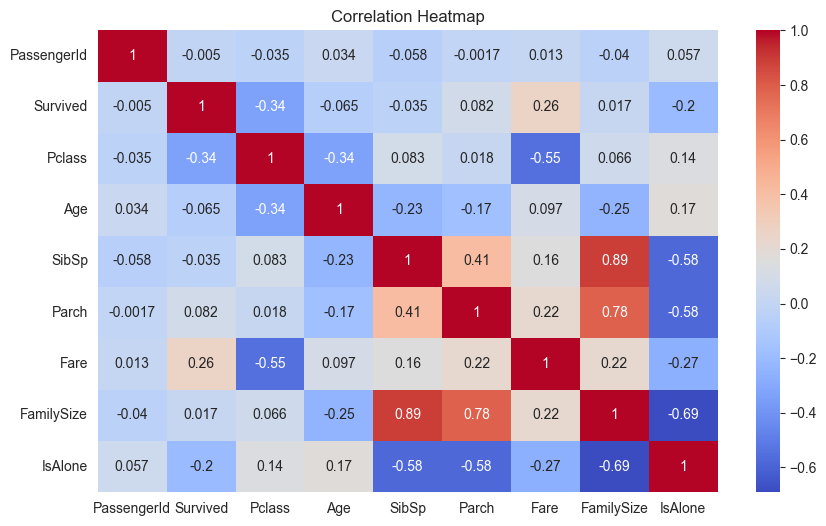

In [16]:
plot_correlation_heatmap(df)

### Insight

Variables such as passenger class, fare, and family size show meaningful relationships with survival probability.

# Logistic Regression Model

Logistic Regression is used as a baseline classification model.

This model is:
- Fast
- Interpretable
- Commonly used for binary classification

In [17]:
lr_model, lr_y_test, lr_predictions = entrenar_modelo(df)

Accuracy: 0.8044692737430168


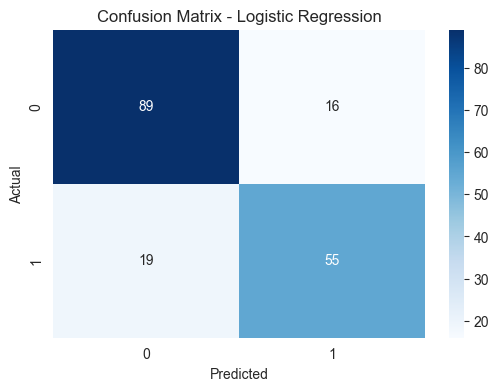

=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



In [18]:
evaluar_modelo(
    lr_y_test,
    lr_predictions,
    model_name="Logistic Regression"
)

In [19]:
# 1. Extraer los coeficientes
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para mapear variable con su coeficiente
importancia_lr = pd.DataFrame({
    'Feature': lr_model.feature_names_in_,
    'Coeficiente': lr_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("=== COEFICIENTES DE REGRESIÓN LOGÍSTICA ===")
print(importancia_lr)

=== COEFICIENTES DE REGRESIÓN LOGÍSTICA ===
      Feature  Coeficiente
8   Title_Mrs     0.480763
2        Fare     0.004982
1         Age    -0.027547
4     IsAlone    -0.345217
3  FamilySize    -0.486974
6  Title_Miss    -0.611954
0      Pclass    -0.838575
5    Sex_male    -1.002631
9  Title_Rare    -1.207310
7    Title_Mr    -2.280055


### Model Interpretation

The Logistic Regression model achieved solid performance and provided a strong baseline for future model comparisons.

# Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Handles non-linear relationships
- Reduces overfitting
- Often performs well on tabular datasets

In [20]:
rf_model, X, rf_y_test, rf_predictions = entrenar_random_forest(df)

Random Forest Accuracy: 0.8212290502793296


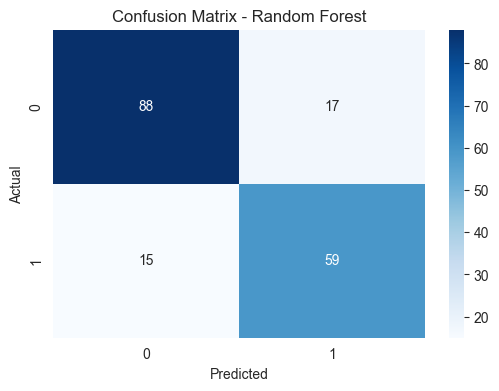

=== Classification Report: Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [21]:
evaluar_modelo(
    rf_y_test,
    rf_predictions,
    model_name="Random Forest"
)

### Model Interpretation

Random Forest improved predictive flexibility and captured more complex interactions between variables.

# Feature Importance

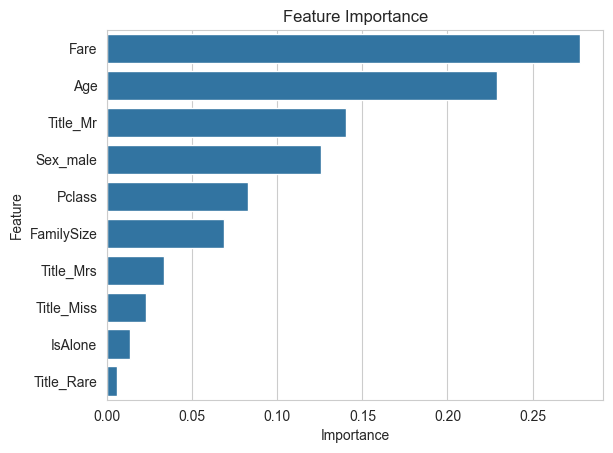

In [22]:
plot_feature_importance(rf_model, X)

### Insight

Feature importance analysis indicates that variables such as sex, fare, passenger class, and age strongly influenced model predictions.

# Pipeline Profesional con Scikit-Learn

In [23]:
from models.pipeline_model import entrenar_pipeline

In [24]:
pipeline_model, y_test, predictions = entrenar_pipeline(df)

Pipeline Accuracy: 0.7988826815642458


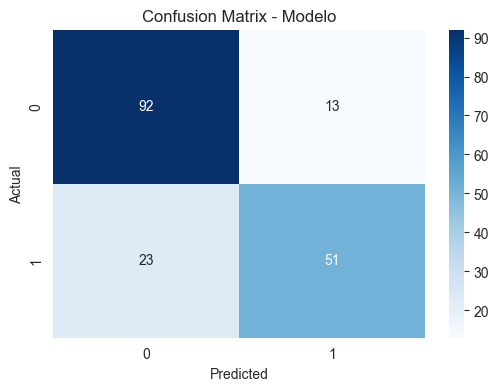

=== Classification Report: Modelo ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [25]:
evaluar_modelo(y_test, predictions)

# Hyperparameter Tuning

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best Score:
0.8356150891362158


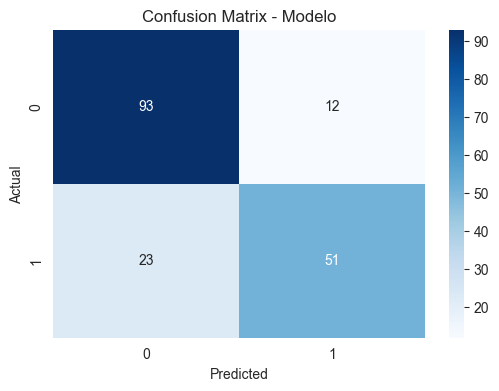

=== Classification Report: Modelo ===
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [26]:
from models.tune_random_forest import (
    optimizar_random_forest
)

best_model, X_test, y_test = (
    optimizar_random_forest(df)
)

predictions = best_model.predict(X_test)

evaluar_modelo(
    y_test,
    predictions
)

# Final Conclusions

## Key Findings

- Female passengers had significantly higher survival rates.
- Passenger class strongly influenced survival probability.
- Feature engineering improved model usefulness.
- Logistic Regression provided a reliable baseline model.
- Random Forest captured more complex patterns and relationships.

---

## Technical Skills Demonstrated

This project demonstrates:

- Data Cleaning
- Exploratory Data Analysis
- Data Visualization
- Feature Engineering
- Machine Learning Classification
- Model Evaluation
- Feature Importance Analysis
- Modular Project Architecture
